# Experiment 1A: ISI — Train-at-f / Eval-at-f Protocol (Learnable Tau + Delay)

## Overview

This notebook implements Experiment 1A from the "Beyond Beyond Rate" project
under the **train-at-f / eval-at-f** protocol. For each perturbation level *f*
we instantiate a fresh SNN (with **learnable tau** AND **learnable axonal
delays**), train it end-to-end on ISI with hidden-layer perturbation active
on every batch, then evaluate at the same *f*.

`delay1` lives on the input side of `_first_layer` (already the clean routing
from `docs/progress/phase1to4_fixes.md` §3.4 Option A); `delay2` lives at
the start of `_second_layer`, after the perturbation hook. The hidden-layer
output of `_first_layer` is therefore strictly binary spikes, exactly what
the spike-relocation perturbation expects. Gradient flow across the hook is
preserved by the same straight-through-estimator wrapper as `isi_tau.ipynb`.

| Property | Value |
|---|---|
| Architecture | Input (10) → Hidden (100, SRMALPHA, learnable tau + delay) → Output (2) |
| Delays | Learnable axonal delays on both layers (max 15 time steps) |
| Training | Fresh model per *f*; perturbation applied at the 1st hidden layer on every batch |
| Evaluation | Same *f* as training; ``NUM_REPEATS`` repeats for error bars |
| Dataset | ISI synthetic (`isi_dataset.h5`) |
| Framework | SLAYER (slayerPytorch) |

Compare with `isi_tau.ipynb` to see whether learnable delays change the
relationship between *f* and residual accuracy.

## 1. Imports and Setup

In [1]:
import os
import sys
import json
import random
import pickle
from typing import Optional

import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import h5py

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
#sys.path.append(os.path.join(CURRENT_DIR, "../../src"))
import slayerSNN as snn

MS = 1e-3  # Millisecond constant

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. SLAYER and Training Parameters

SLAYER requires neuron and simulation descriptors. We use SRMALPHA neurons
with a 1 ms sampling period and 1000 ms sample duration, matching the ISI
dataset time steps. The delay variant adds learnable axonal delays (max 15
time steps) on both layers.

In [2]:
# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 1000}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 1,
    "tauSr": 1,
    "tauRho": 1,
    "tauRef": 1,
    "scaleRef": 2,
    "scaleRho": 1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS = 100
EPOCHS = 301
BATCH_SIZE = 32
LEARNING_RATE = 0.001
SEED = 48
MAX_DELAY = 15  # Maximum learnable delay in time steps

# --- Train-at-f / eval-at-f sweep ---
F_VALUES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS = 3
MODEL_PREFIX = "isi_delay"

## 3. Load ISI Dataset

Load the ISI spike-train dataset from the local HDF5 file.
Each sample has shape `(num_neurons, T)` with binary spike values.

In [3]:
def load_isi_data(data_file: str = "isi_dataset.h5"):
    """Load ISI dataset from HDF5 file.

    Args:
        data_file: Path to the HDF5 file.

    Returns:
        Tuple of (X, Y, firing_rates, isis) arrays.
    """
    with h5py.File(data_file, "r") as f:
        X = f["X"][:]  # (N, num_neurons, T)
        Y = f["Y"][:].ravel()
        firing_rates = f["firing_rates"][:] if "firing_rates" in f else None
        isis = f["isis"][:] if "isis" in f else None

    print(f"Loaded {data_file}: X={X.shape}, Y={Y.shape}")
    print(f"Classes: {np.unique(Y)}, Time steps: {X.shape[2]}")
    return X, Y, firing_rates, isis


X_all, Y_all, firing_rates_all, isis_all = load_isi_data("isi_dataset.h5")
NUM_NEURONS = X_all.shape[1]
NUM_CLASSES = len(np.unique(Y_all))
print(f"Network config: {NUM_NEURONS} input neurons, {NUM_CLASSES} classes")

Loaded isi_dataset.h5: X=(3598, 10, 1000), Y=(3598,)
Classes: [0 1], Time steps: 1000
Network config: 10 input neurons, 2 classes


## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This destroys temporal
structure while preserving each neuron's spike count (i.e. the rate code).

In [4]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref impl).

    Kept for documentation / numpy-only callers. The training and evaluation
    paths use the vectorised GPU version ``perturb_hidden_batch`` below.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).
        max_attempts: Max placement retries per spike.

    Returns:
        Perturbed spike train with the same shape.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        num_to_move = int(len(spike_times) * f)
        if num_to_move == 0:
            continue

        chosen = np.random.choice(spike_times, size=num_to_move, replace=False)
        new_train[neuron_idx, chosen] = 0

        placed = 0
        for _ in range(max_attempts * num_to_move):
            if placed >= num_to_move:
                break
            new_t = np.random.randint(0, T)
            if new_train[neuron_idx, new_t] == 0:
                new_train[neuron_idx, new_t] = 1
                placed += 1

    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when
    perturbation runs on every batch.

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    # rank[b, c, t] = position of t in the per-(b,c) ascending sort of `key`.
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move  # (B, C, T)

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask  # everything except positions we are keeping
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to split into train / validation / test
sets. Training always uses **unperturbed** data (f=0); perturbation is applied
only at test time inside the network's forward pass.

In [5]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(split_range: tuple[float, float], total: int) -> np.ndarray:
    """Return integer indices for the given fractional range."""
    return np.arange(int(split_range[0] * total), int(split_range[1] * total))


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 32,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split data and return train / val / test DataLoaders (no perturbation)."""
    train_idx = get_split_indices(TRAIN_RANGE, len(X))
    val_idx = get_split_indices(VAL_RANGE, len(X))
    test_idx = get_split_indices(TEST_RANGE, len(X))

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Split sizes — Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A single-hidden-layer SLAYER SNN with a **learnable PSP filter** AND
**learnable axonal delays** on both layers.

```
Input (10) → [delay1 + psp_filter + fc1 + spike] → Hidden (100)
                                                       ↓
                              ← perturbation hook (STE) applied here
                                                       ↓
                              [delay2 + psp + fc2 + spike] → Output (2)
```

The hidden-layer output of ``_first_layer`` is strictly binary (the spike
function is the last op), so ``perturb_hidden_batch`` operates on the
correct representation. ``forward(x, f)`` routes the hidden spikes
through ``_apply_perturbation`` — a straight-through estimator that
preserves gradient flow to ``fc1``, ``psp_filter`` and ``delay1``.

In [6]:
class ISIDelayNetwork(nn.Module):
    """SLAYER SNN for ISI classification with learnable tau AND axonal delays.

    ``delay1`` acts on the input side of ``_first_layer`` (per-input-neuron
    axonal delay); ``delay2`` sits at the start of ``_second_layer`` (after
    the perturbation hook). The output of ``_first_layer`` is strictly
    binary, so the spike-relocation perturbation in ``perturb_hidden_batch``
    operates on the correct representation.

    ``forward(x, f)`` applies the perturbation through a straight-through
    estimator so ``fc1`` / ``psp_filter`` / ``delay1`` still receive gradient
    when training at ``f > 0``.
    """

    def __init__(
        self,
        num_neurons: int,
        num_classes: int,
        hidden_units: int = 100,
        max_delay: int = 15,
    ):
        super().__init__()
        self.max_delay = max_delay
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(num_neurons, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        self.psp_filter = slayer.pspFilter(nFilter=1, filterLength=50, filterScale=1)
        self._initialize_alpha_filter()

        # delay1 acts on the input side (before fc1+spike); delay2 sits at
        # the start of _second_layer, after the perturbation hook. This
        # keeps the hidden-layer output strictly binary.
        self.delay1 = slayer.delay(num_neurons)
        self.delay2 = slayer.delay(hidden_units)
        self._initialize_delays()

    # ------------------------------------------------------------------
    # Initialisation helpers
    # ------------------------------------------------------------------
    def _initialize_alpha_filter(self) -> None:
        """Seed the learnable PSP filter with an alpha-function shape."""
        tau = 50 * MS
        Ts = self.slayer.simulation["Ts"] * MS
        filt_len = self.psp_filter.weight.shape[-1]
        alpha_kernel = np.array([
            t / tau * np.exp(1 - t / tau)
            for t in np.arange(0, filt_len * Ts, Ts)
        ])
        if np.max(np.abs(alpha_kernel)) > 0:
            alpha_kernel /= np.max(np.abs(alpha_kernel))
        with torch.no_grad():
            self.psp_filter.weight.data = torch.FloatTensor(
                np.flip(alpha_kernel).copy()
            ).reshape(self.psp_filter.weight.shape)

    def _initialize_delays(self) -> None:
        """Initialize delay parameters uniformly in [0, max_delay]."""
        with torch.no_grad():
            if hasattr(self.delay1, "delay"):
                self.delay1.delay.data.uniform_(0, self.max_delay)
            if hasattr(self.delay2, "delay"):
                self.delay2.delay.data.uniform_(0, self.max_delay)

    def get_tau(self) -> torch.Tensor:
        """Estimate the effective tau from the learned filter."""
        weights = self.psp_filter.weight.data.squeeze().cpu().numpy()
        weights = np.flip(weights)
        if len(weights) > 0:
            peak_idx = np.argmax(np.abs(weights))
            estimated_tau = 3 * peak_idx * self.slayer.simulation["Ts"] * MS
            return torch.tensor(max(estimated_tau, 10 * MS))
        return torch.tensor(50 * MS)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Get current delay values as numpy arrays."""
        delays: dict[str, np.ndarray] = {}
        if hasattr(self.delay1, "delay"):
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
        if hasattr(self.delay2, "delay"):
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

    # ------------------------------------------------------------------
    # Forward passes
    # ------------------------------------------------------------------
    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_layer(self, x: torch.Tensor) -> torch.Tensor:
        """Input → hidden spikes (delay1 + learnable PSP + fc1 + spike)."""
        x = self.delay1(x)
        x_filtered = self.psp_filter(x)
        return self.slayer.spike(self.fc1(x_filtered))

    def _second_layer(self, hidden_spikes: torch.Tensor) -> torch.Tensor:
        """Hidden spikes → output spikes (delay2 + standard PSP + fc2)."""
        x = self.delay2(hidden_spikes)
        return self.slayer.spike(self.fc2(self.slayer.psp(x)))

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """STE wrapper around ``perturb_hidden_batch``.

        See Section 7.1 of ``docs/progress/phase1to4_fixes.md`` for the
        backward-pass reasoning. Without this, ``fc1`` / ``psp_filter`` /
        ``delay1`` would not receive gradient under ``f > 0``.
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*."""
        x = self._prepare_input(x)
        hidden = self._first_layer(x)
        hidden = self._apply_perturbation(hidden, f)
        return self._second_layer(hidden)

## 7. Training Loop

Train one model with perturbation level *f* active on every training and
validation batch. ProbSpikes loss, Nadam optimiser with three parameter
groups — regular at base LR, PSP filter (tau) at ×10, delays at ×5 —
plus a step-LR schedule. Best checkpoint by validation loss is restored.

In [7]:
def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_neurons: int,
    num_classes: int,
    hidden_units: int = 100,
    max_delay: int = 15,
    epochs: int = 301,
    lr: float = 0.001,
    seed: int = 42,
    f: float = 0.0,
) -> tuple["ISIDelayNetwork", dict]:
    """Train the ISIDelayNetwork end-to-end with perturbation level *f* active.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        num_neurons: Number of input neurons.
        num_classes: Number of output classes.
        hidden_units: Hidden layer size.
        max_delay: Maximum learnable delay in time steps.
        epochs: Number of training epochs.
        lr: Base learning rate.
        seed: Random seed; re-seeded inside so each f starts from the same init.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained network, training log dict).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    net = ISIDelayNetwork(num_neurons, num_classes, hidden_units, max_delay).to(device)

    loss_fn = snn.spikeLoss.spikeLoss({
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {"error": {"type": "ProbSpikes"}},
    }).to(device)

    # Three parameter groups with different learning rates.
    regular_params, tau_params, delay_params = [], [], []
    for name, param in net.named_parameters():
        if "delay" in name:
            delay_params.append(param)
        elif "psp_filter" in name:
            tau_params.append(param)
        else:
            regular_params.append(param)

    param_groups = [{"params": regular_params, "lr": lr}]
    if tau_params:
        param_groups.append({"params": tau_params, "lr": lr * 10})
    if delay_params:
        param_groups.append({"params": delay_params, "lr": lr * 5})

    optimizer = snn.utils.optim.Nadam(param_groups)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.5,
    )

    best_val_loss = float("inf")
    best_model_state = None
    tau_history: list[float] = []
    delay_history: list[dict] = []

    log: dict = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "tau": [],
        "delay_mean": [],
        "f": f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            epoch_loss = 0.0
            batch_count = 0

            for x_batch, y_batch in train_loader:
                if x_batch.dim() == 3:
                    x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                x_batch = x_batch.to(device).float()
                y_batch = y_batch.to(device).long()

                outputs = net(x_batch, f=f)
                loss = loss_fn.probSpikes(outputs, y_batch)
                epoch_loss += loss.item()
                batch_count += 1

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                pbar.update(1)

            # --- Validate ---
            net.eval()
            val_loss = 0.0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    if x_batch.dim() == 3:
                        x_batch = x_batch.unsqueeze(2).unsqueeze(3)
                    x_batch = x_batch.to(device).float()
                    y_batch = y_batch.to(device).long()
                    outputs = net(x_batch, f=f)
                    val_loss += loss_fn.probSpikes(outputs, y_batch).item()

            val_loss /= len(val_loader)
            epoch_loss /= batch_count
            tau_val = net.get_tau().item() / MS
            tau_history.append(tau_val)

            delays = net.get_delays()
            delay_history.append(delays)
            avg_delay = (
                np.mean([np.mean(d) for d in delays.values() if len(d) > 0])
                if delays else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(epoch_loss)
            log["val_loss"].append(val_loss)
            log["tau"].append(tau_val)
            log["delay_mean"].append(float(avg_delay))

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.clone() for k, v in net.state_dict().items()}

            scheduler.step()
            pbar.set_postfix(
                epoch=epoch + 1,
                val_loss=f"{val_loss:.4f}",
                best=f"{best_val_loss:.4f}",
                tau=f"{tau_val:.1f}ms",
                delay=f"{avg_delay:.1f}",
            )

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    log["tau_history"] = tau_history
    log["delay_history_mean"] = [
        float(np.mean([np.mean(d) for d in dh.values() if len(d) > 0])) if dh else 0.0
        for dh in delay_history
    ]
    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the hidden layer and
the spike output is perturbed before being fed to the second layer.

In [8]:
def test_with_hidden_perturbation(
    net: ISIDelayNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*."""
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            if x_batch.dim() == 3:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3)
            x_batch = x_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: ISIDelayNetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` for mean ± std."""
    accuracies: list[float] = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, tau evolution, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [9]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, tau evolution, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    f_val = log.get("f", 0.0)

    # Loss curves
    axes[0].plot(log["epoch"], log["train_loss"], "o-", label="Train loss", markersize=2)
    axes[0].plot(log["epoch"], log["val_loss"], "s-", label="Val loss", markersize=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Training and Validation Loss (f={f_val})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tau evolution
    axes[1].plot(log["tau_history"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Tau (ms)")
    axes[1].set_title(f"Learned Tau Over Training (f={f_val})")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    axes[2].plot(log["delay_history_mean"])
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean Delay (time steps)")
    axes[2].set_title(f"Average Delay Over Training (f={f_val})")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(results: dict[float, dict]) -> None:
    """Plot accuracy vs hidden perturbation level f (train-at-f / eval-at-f)."""
    f_vals = sorted(results.keys())
    means = [results[f]["mean"] for f in f_vals]
    stds = [results[f]["std"] for f in f_vals]

    plt.figure(figsize=(8, 5))
    plt.errorbar(f_vals, means, yerr=stds, fmt="o-", capsize=5, capthick=2,
                 color="tab:orange", label="SGD-delay (learnable tau + delay)")
    plt.xlabel("Hidden Perturbation Level (f) — trained & evaluated at this f")
    plt.ylabel("Test Accuracy")
    plt.title("Exp 1A — ISI: Train-at-f / Eval-at-f (Learnable Tau + Delay)")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.savefig("log/isi_delay_hidden_perturbation.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Figure saved to log/isi_delay_hidden_perturbation.png")

## 10. Run: Train-at-f / Eval-at-f Sweep

For each *f* in ``F_VALUES`` we instantiate a fresh model from ``SEED``,
train with that perturbation level active, save the checkpoint with *f*
baked into the filename, then evaluate at the same *f*.

In [10]:
# Build DataLoaders. Perturbation is applied inside the forward pass.
train_loader, val_loader, test_loader = build_dataloaders(
    X_all, Y_all, batch_size=BATCH_SIZE,
)

os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

all_models: dict[float, ISIDelayNetwork] = {}
all_logs: dict[float, dict] = {}
sweep_results: dict[float, dict] = {}

for f_val in F_VALUES:
    print(f"\n=== Training at f={f_val} ===")
    net, training_log = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        num_neurons=NUM_NEURONS,
        num_classes=NUM_CLASSES,
        hidden_units=HIDDEN_UNITS,
        max_delay=MAX_DELAY,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        seed=SEED,
        f=f_val,
    )

    model_path = f"data/{MODEL_PREFIX}_f{f_val}.pt"
    torch.save(net.state_dict(), model_path)

    result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
    all_models[f_val] = net
    all_logs[f_val] = training_log
    sweep_results[f_val] = result
    print(
        f"f={f_val} | test acc = {result['mean']:.4f} ± {result['std']:.4f}"
        f" | checkpoint -> {model_path}"
    )

Split sizes — Train: 2158, Val: 540, Test: 540

=== Training at f=0.0 ===


d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Train f=0.0:   0%|          | 0/20468 [00:00<?, ?it/s]d:\IC_2025\IRP\workspace\venv\Lib\site-packages\slayersnn-0.0.0-py3.11.egg\slayerSNN\optimizer.py:94: UserWarning: This overload of add_ is deprecated:
	add_(Number alpha, Tensor other)
Consider using one of the following signatures instead:
	add_(Tensor other, *, Number alpha = 1) (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\python_arg_parser.cpp:1691.)
  exp_avg.mul_(beta1).add_(1 - beta1, grad)
Train f=0.0: 100%|██████████| 20468/20468 [07:32<00:00, 45.23it/s, best=0.2174, delay=7.3, epoch=301, tau=123.0ms, val_loss=0.2345]
d:\IC_2025\IRP\workspace\venv\Lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is 

f=0.0 | test acc = 0.9370 ± 0.0000 | checkpoint -> data/isi_delay_f0.0.pt

=== Training at f=0.2 ===


Train f=0.2: 100%|██████████| 20468/20468 [16:30<00:00, 20.67it/s, best=0.2201, delay=7.6, epoch=301, tau=114.0ms, val_loss=0.2254]


f=0.2 | test acc = 0.9605 ± 0.0017 | checkpoint -> data/isi_delay_f0.2.pt

=== Training at f=0.4 ===


...

f=0.6 | test acc = 0.9228 ± 0.0053 | checkpoint -> data/isi_delay_f0.6.pt

=== Training at f=0.8 ===


Train f=0.8: 100%|██████████| 20468/20468 [17:02<00:00, 20.02it/s, best=0.1612, delay=7.6, epoch=301, tau=120.0ms, val_loss=0.2680]


f=0.8 | test acc = 0.9426 ± 0.0040 | checkpoint -> data/isi_delay_f0.8.pt

=== Training at f=1.0 ===


Train f=1.0: 100%|██████████| 20468/20468 [16:49<00:00, 20.28it/s, best=0.1497, delay=7.9, epoch=301, tau=117.0ms, val_loss=0.1644]


f=1.0 | test acc = 0.9500 ± 0.0052 | checkpoint -> data/isi_delay_f1.0.pt


## 10b. Diagnostic — STE Health Check

Per §3.6 / §5 of `docs/progress/phase1to4_fixes.md`. Two `f>0` rows with
identical `fc1.norm` mean the STE regressed; non-binary `hidden_unique`
means the perturbation hook is seeing the wrong tensor (Issue 2). Delay
norms shown so we can spot a delay that never updated.

In [11]:
print(f"{'f':>6}  {'fc1.norm':>10}  {'psp.norm':>10}  {'d1.mean':>8}  {'d2.mean':>8}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    psp_norm = mdl.psp_filter.weight.norm().item()
    delays = mdl.get_delays()
    d1_mean = float(np.mean(delays.get("delay1", [0.0])))
    d2_mean = float(np.mean(delays.get("delay2", [0.0])))
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        if x_b.dim() == 3:
            x_b = x_b.unsqueeze(2).unsqueeze(3)
        x_b = x_b.to(device).float()
        hidden = mdl._first_layer(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(
        f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {psp_norm:>10.4f}  "
        f"{d1_mean:>8.3f}  {d2_mean:>8.3f}  {unique}"
    )

     f    fc1.norm    psp.norm   d1.mean   d2.mean  hidden_unique
  0.00    114.4507      5.5518     6.681     7.704  [0.0, 1.0]
  0.20    114.4466      6.0728     7.706     7.495  [0.0, 1.0]
  0.40    114.9652      6.4339     7.116     7.687  [0.0, 1.0]
  0.60    114.6294      5.8253     6.825     7.412  [0.0, 1.0]
  0.80    114.9117      5.9266     7.433     7.752  [0.0, 1.0]
  1.00    114.7533      6.0434     7.948     7.639  [0.0, 1.0]


## 11. Plot Training Curves

Plot training/validation loss, tau evolution and delay evolution for the
trained model.


--- Training curves at f=0.0 ---


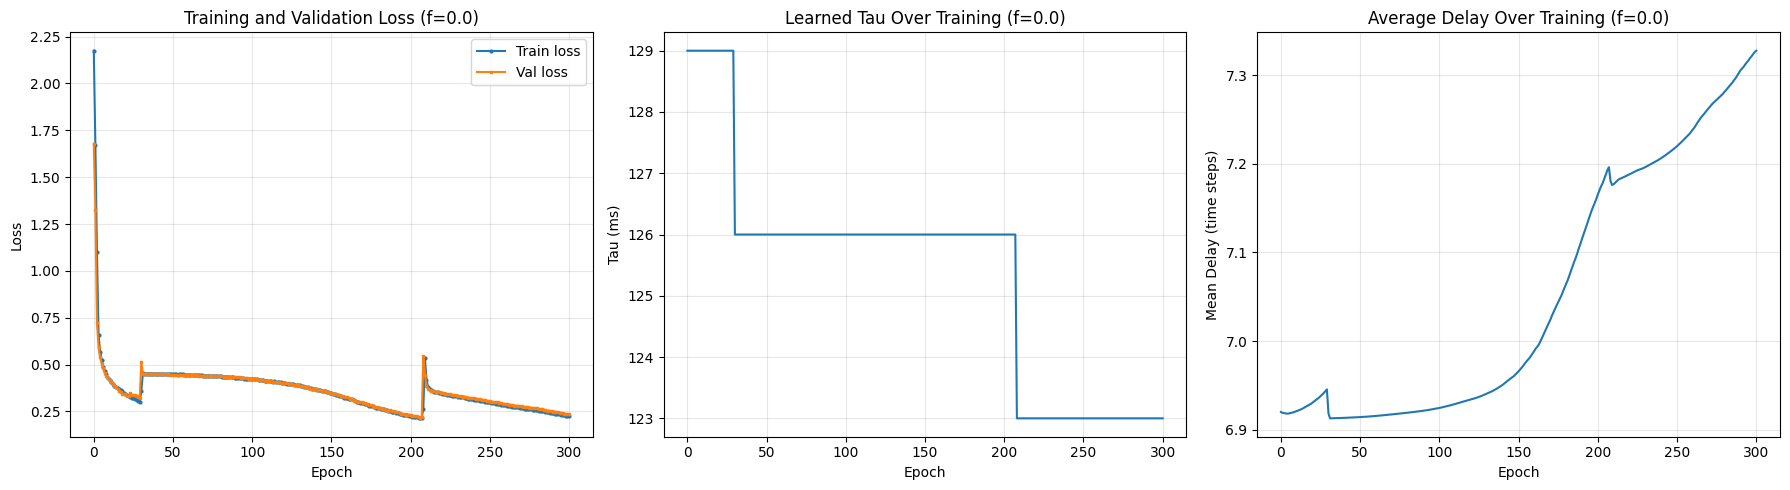


--- Training curves at f=0.2 ---


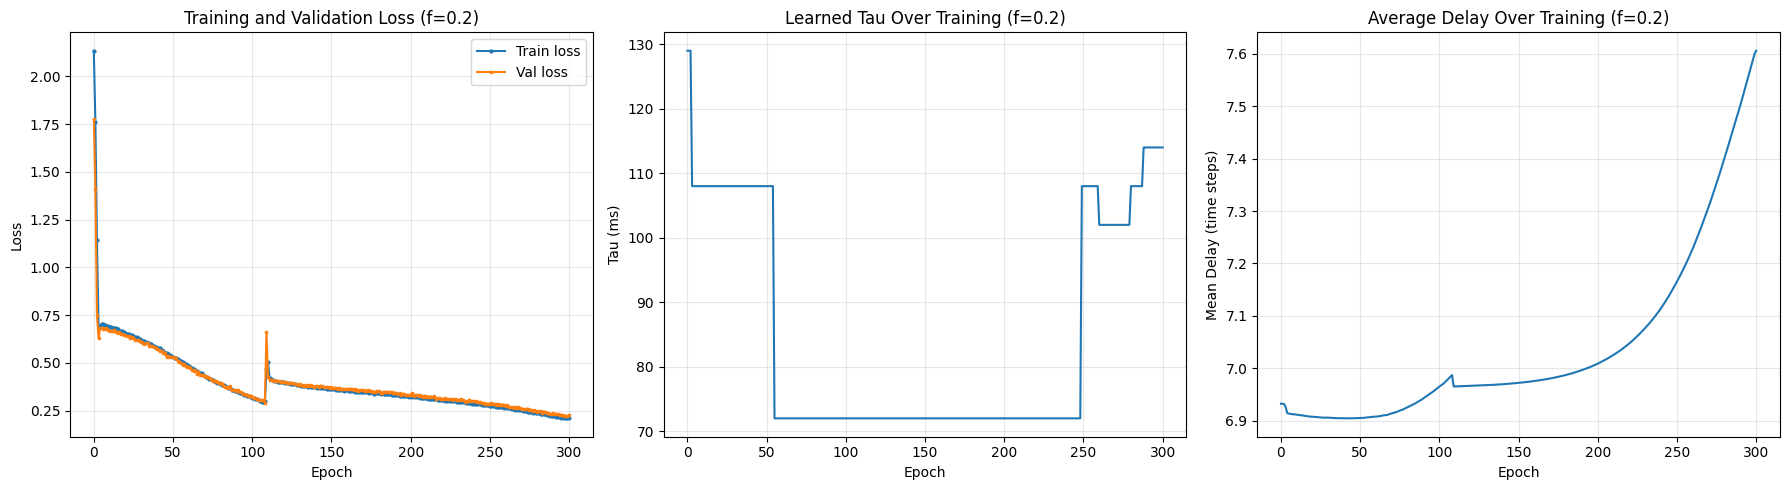


--- Training curves at f=0.4 ---


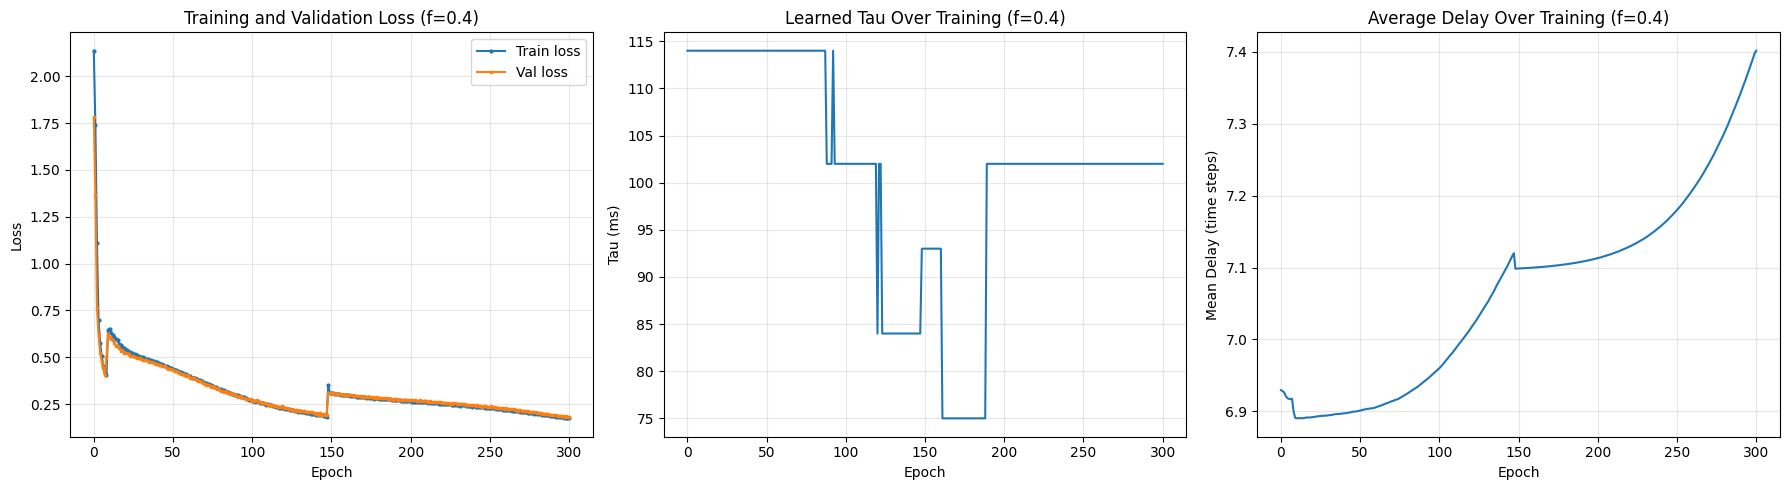


--- Training curves at f=0.6 ---


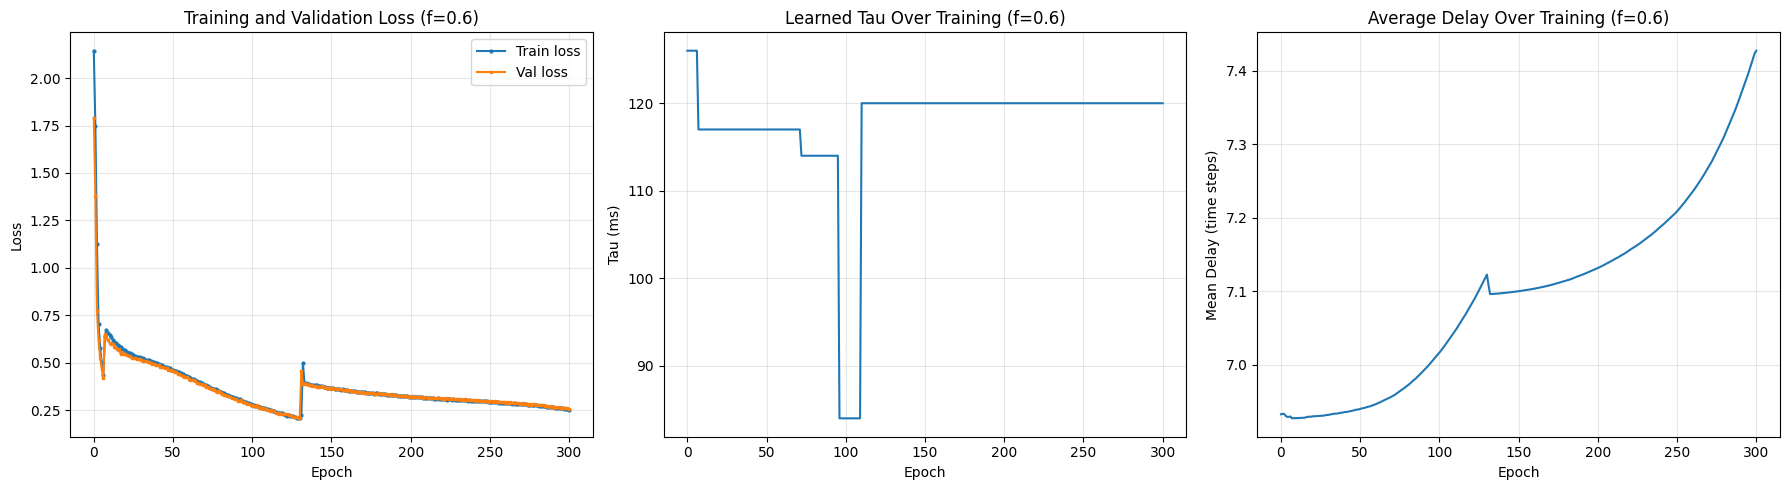


--- Training curves at f=0.8 ---


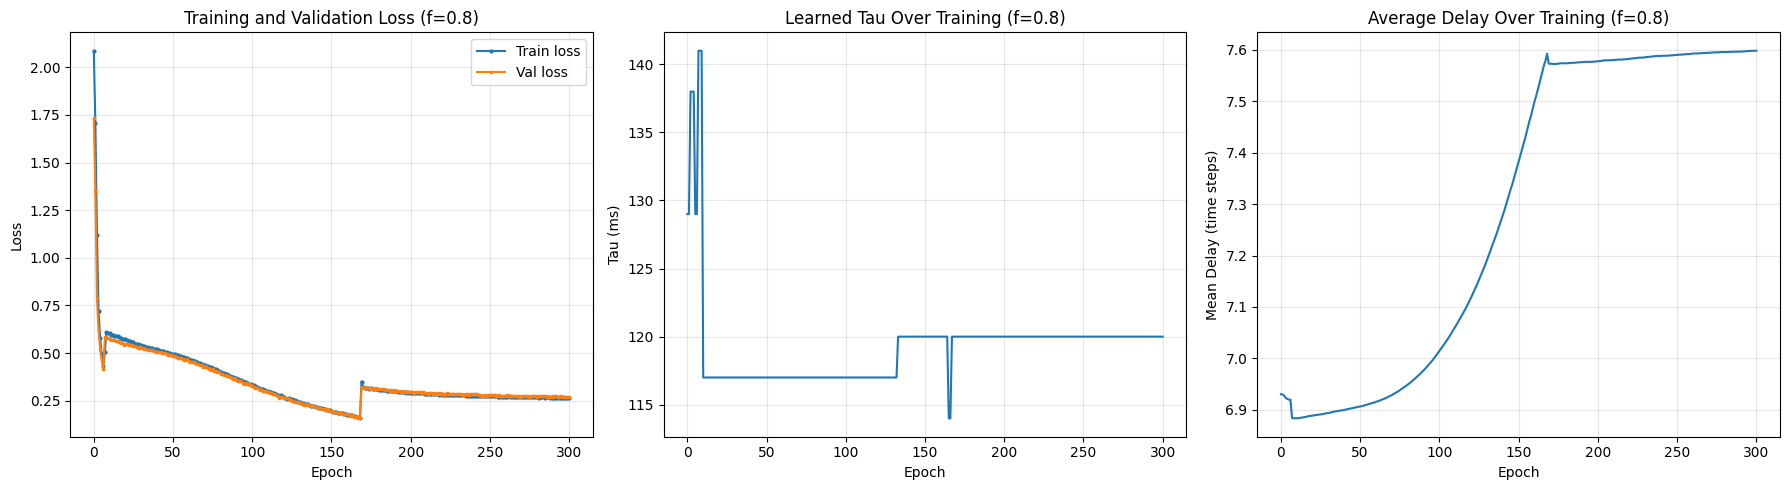


--- Training curves at f=1.0 ---


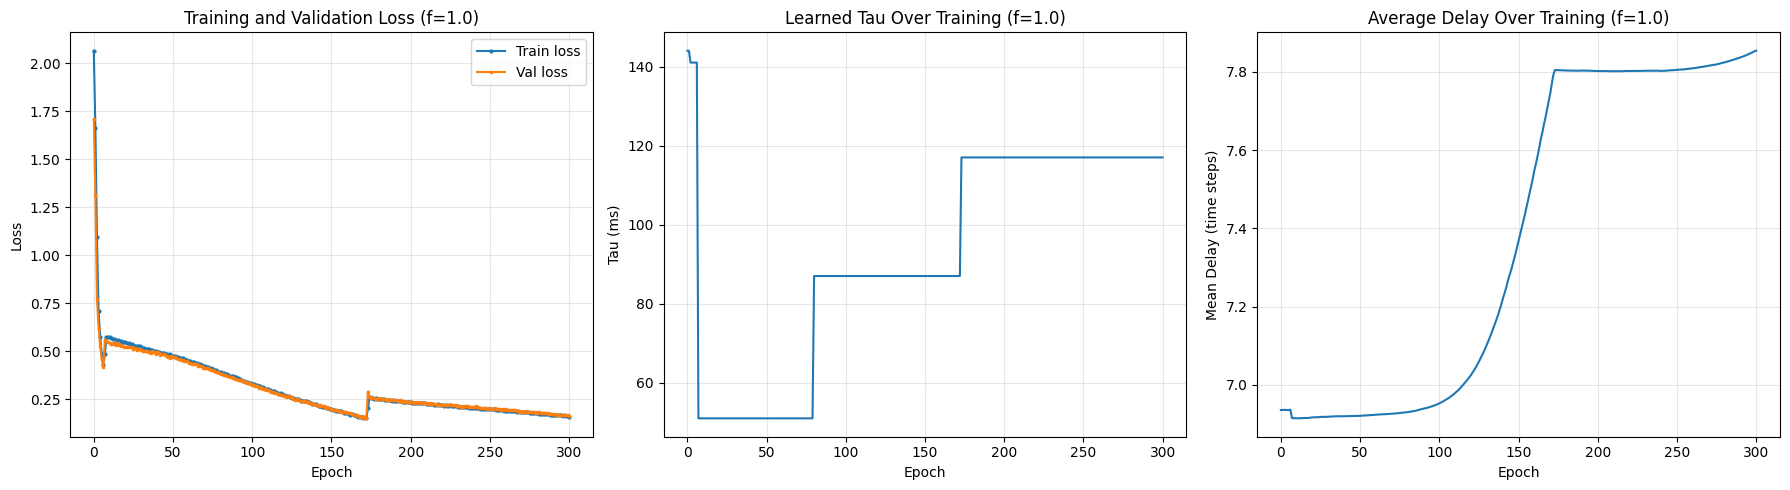

In [12]:
for f_val in F_VALUES:
    print(f"\n--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

The sweep was already executed in §10. Print accuracies for inspection.

In [13]:
print("=== Train-at-f / Eval-at-f Sweep Summary (ISI, learnable tau + delay) ===")
for f_val in sorted(sweep_results.keys()):
    data = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {data['mean']:.4f} +/- {data['std']:.4f}")

=== Train-at-f / Eval-at-f Sweep Summary (ISI, learnable tau + delay) ===
  f=0.0:  accuracy = 0.9370 +/- 0.0000
  f=0.2:  accuracy = 0.9605 +/- 0.0017
  f=0.4:  accuracy = 0.9636 +/- 0.0009
  f=0.6:  accuracy = 0.9228 +/- 0.0053
  f=0.8:  accuracy = 0.9426 +/- 0.0040
  f=1.0:  accuracy = 0.9500 +/- 0.0052


## 13. Plot Hidden-Perturbation Results

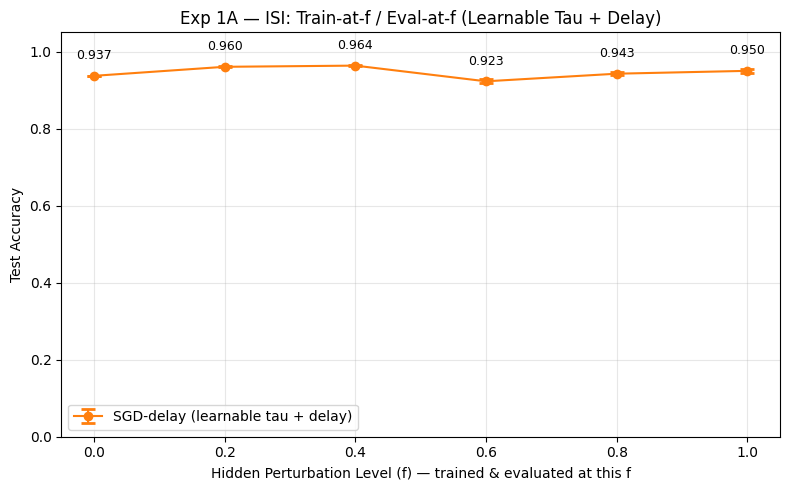

Figure saved to log/isi_delay_hidden_perturbation.png


In [14]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the perturbation sweep results and training log to JSON for later
comparison with `isi_tau.ipynb` (SGD tau-only model) and with the original
input-perturbation baseline from Beyond Rate.

In [15]:
# Save perturbation sweep results
results_serialisable = {
    str(f_val): {
        "mean": float(data["mean"]),
        "std": float(data["std"]),
        "values": [float(v) for v in data["values"]],
    }
    for f_val, data in sweep_results.items()
}

results_path = f"log/{MODEL_PREFIX}_hidden_perturbation_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Perturbation results saved to {results_path}")

# Save per-f training logs
training_logs_serialisable = {
    str(f_val): {
        k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
        for k, vals in log.items()
    }
    for f_val, log in all_logs.items()
}
log_path = f"log/{MODEL_PREFIX}_training_log.json"
with open(log_path, "w") as fp:
    json.dump(training_logs_serialisable, fp, indent=2)
print(f"Training logs saved to {log_path}")

Perturbation results saved to log/isi_delay_hidden_perturbation_results.json
Training logs saved to log/isi_delay_training_log.json


## 15. Model Analysis

Inspect the learned tau, delay distributions, PSP filter shape, and
per-layer weight statistics.

=== Learned Parameter Analysis (ISI, learnable tau + delay) ===

     f    tau (ms)    d1 mean     d1 std    d2 mean     d2 std
   0.0      126.00      6.681      3.487      7.704      4.367
   0.2      114.00      7.706      3.508      7.495      4.288
   0.4      102.00      7.116      3.502      7.687      4.546
   0.6      120.00      6.825      3.305      7.412      4.422
   0.8      120.00      7.433      3.420      7.752      5.037
   1.0       87.00      7.948      4.977      7.639      4.475


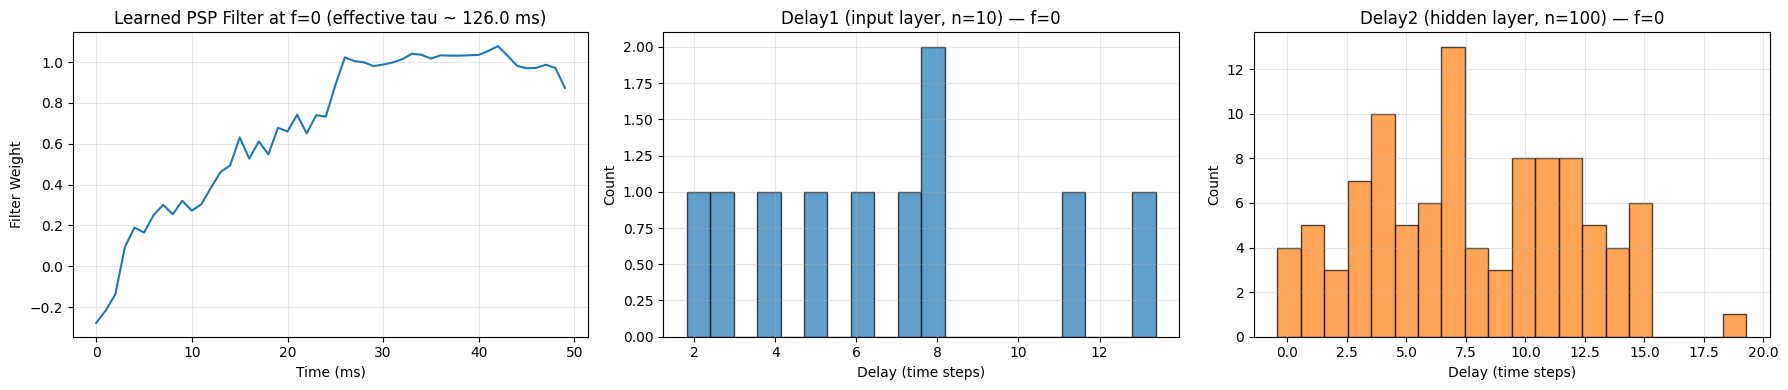


Weight statistics (f=0 baseline):
  fc1.weight_g: mean=5.6767, std=0.9006, shape=[100, 1, 1, 1, 1]
  fc1.weight_v: mean=0.0339, std=1.8025, shape=[100, 10, 1, 1, 1]
  fc2.weight_g: mean=6.0888, std=0.6196, shape=[2, 1, 1, 1, 1]
  fc2.weight_v: mean=-0.0559, std=0.6094, shape=[2, 100, 1, 1, 1]
  psp_filter.weight: mean=0.6892, std=0.3798, shape=[1, 1, 1, 1, 50]


In [16]:
print("=== Learned Parameter Analysis (ISI, learnable tau + delay) ===\n")

print(f"{'f':>6}  {'tau (ms)':>10}  {'d1 mean':>9}  {'d1 std':>9}  {'d2 mean':>9}  {'d2 std':>9}")
for f_val, mdl in all_models.items():
    tau_v = mdl.get_tau().item() / MS
    d = mdl.get_delays()
    d1 = d.get("delay1")
    d2 = d.get("delay2")
    d1m = float(np.mean(d1)) if d1 is not None and len(d1) > 0 else float("nan")
    d1s = float(np.std(d1)) if d1 is not None and len(d1) > 0 else float("nan")
    d2m = float(np.mean(d2)) if d2 is not None and len(d2) > 0 else float("nan")
    d2s = float(np.std(d2)) if d2 is not None and len(d2) > 0 else float("nan")
    print(f"{f_val:>6.1f}  {tau_v:>10.2f}  {d1m:>9.3f}  {d1s:>9.3f}  {d2m:>9.3f}  {d2s:>9.3f}")

# Detailed PSP filter / delay plots for the f=0 baseline model
baseline = all_models[0.0]
tau_val = baseline.get_tau().item() / MS
filter_weights = baseline.psp_filter.weight.data.squeeze().cpu().numpy()
delays = baseline.get_delays()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(np.flip(filter_weights))
axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Filter Weight")
axes[0].set_title(f"Learned PSP Filter at f=0 (effective tau ~ {tau_val:.1f} ms)")
axes[0].grid(True, alpha=0.3)

if "delay1" in delays and len(delays["delay1"]) > 0:
    axes[1].hist(
        delays["delay1"].flatten(), bins=20,
        color="tab:blue", alpha=0.7, edgecolor="black",
    )
    axes[1].set_xlabel("Delay (time steps)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Delay1 (input layer, n={delays['delay1'].size}) — f=0")
    axes[1].grid(True, alpha=0.3)

if "delay2" in delays and len(delays["delay2"]) > 0:
    axes[2].hist(
        delays["delay2"].flatten(), bins=20,
        color="tab:orange", alpha=0.7, edgecolor="black",
    )
    axes[2].set_xlabel("Delay (time steps)")
    axes[2].set_ylabel("Count")
    axes[2].set_title(f"Delay2 (hidden layer, n={delays['delay2'].size}) — f=0")
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWeight statistics (f=0 baseline):")
for name, param in baseline.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"  {name}: mean={w.mean().item():.4f}, std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )